In [1]:
import numpy as np
import pandas as pd 
from scipy.stats import zscore
from scipy import stats
from helpers import *
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import roc_auc_score

In [2]:
# 2. Signal binarization and anavalnches construction
fs = 5000
bin_size = int(0.004 * fs)       # 20 samples for a binning of 4 ms
z_thresh= 2
n_regions = 62
patient_atm = {}
control_atm = {}

In [3]:
# 1. Load and process data in order to extract features and ATMs
root_acute = [ "/Volumes/MB_fall_2025//NeuronalAvalanches_dataset/acutestroke_data_combineflipping_final/flipped_rightlesion", 
              "/Volumes/MB_fall_2025//NeuronalAvalanches_dataset/acutestroke_data_combineflipping_final/unflipped_leftlesion"]
root_healthycontrols = "/Volumes/MB_fall_2025//NeuronalAvalanches_dataset/healthyold_data"
feature_acute = {}
atm_acute = {}
for root in root_acute:
    f_a, a_tm = process_group (root, "acute", fs, bin_size, z_thresh, n_regions)
    feature_acute.update(f_a)
    atm_acute.update(a_tm)

feature_healthy, atm_healthy= process_group(root_healthycontrols, "healthy", fs, bin_size, z_thresh, n_regions)

Loading TiMeS_WP11_001 ...
Loading TiMeS_WP11_002 ...
Loading TiMeS_WP11_003 ...
Loading TiMeS_WP11_007 ...
Loading TiMeS_WP11_008 ...
Loading TiMeS_WP11_011 ...
Loading TiMeS_WP11_013 ...
Loading TiMeS_WP11_014 ...
Loading TiMeS_WP11_016 ...
Loading TiMeS_WP11_021 ...
Loading TiMeS_WP11_023 ...
Loading TiMeS_WP11_025 ...
Loading TiMeS_WP11_027 ...
Loading TiMeS_WP11_030 ...
Loading TiMeS_WP11_031 ...
Loading TiMeS_WP11_032 ...
Loading TiMeS_WP11_036 ...
Loading TiMeS_WP11_039 ...
Loading TiMeS_WP11_040 ...
Loading TiMeS_WP11_047 ...
Loading TiMeS_WP11_048 ...
Loading TiMeS_WP11_057 ...
Loading TiMeS_WP11_060 ...
Loading TiMeS_WP11_068 ...
Loading TiMeS_WP11_074 ...
Loading TiMeS_WP11_075 ...
Loading TiMeS_WP11_078 ...
Loading TiMeS_WP11_082 ...
Processing patient TiMeS_WP11_001 (29 epochs)
2695 avalanches found in the binned signal
1.0789092220910403
Saved ATM plot for TiMeS_WP11_001 → atm_plots/TiMeS_WP11_001_ATM.png
Processing patient TiMeS_WP11_002 (25 epochs)
1508 avalanches found

In [4]:
print ("Number of patients in acute group: ", len(atm_acute))
print ("Number of healthy controls: ", len(atm_healthy))

Number of patients in acute group:  54
Number of healthy controls:  14


In [5]:
# 2. Create dataframes for features and ATMs
rows = []
# Acute patients
for patient_id, features in feature_acute.items():
    row = {"patent_id" : patient_id, "group": "acute"}
    row.update(features)
    rows.append(row)
# Healthy controls
for control_id, features in feature_healthy.items():
    row = {"patent_id" : control_id,  "group": "healthy"}
    row.update(features)
    rows.append(row)

df_features = pd.DataFrame(rows)

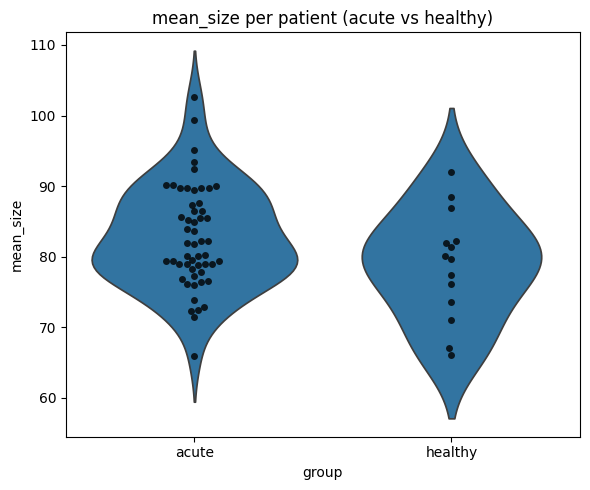

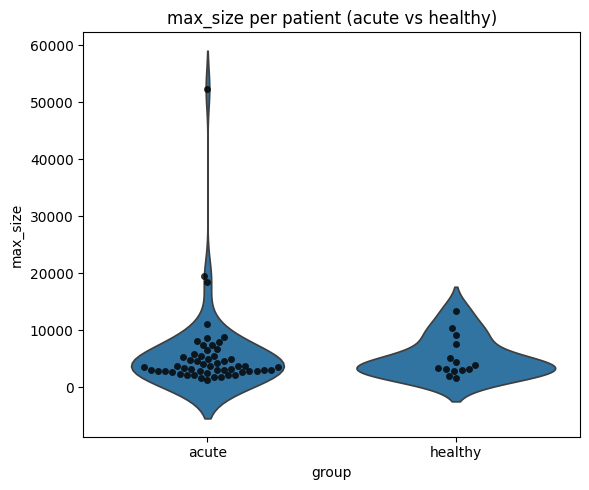

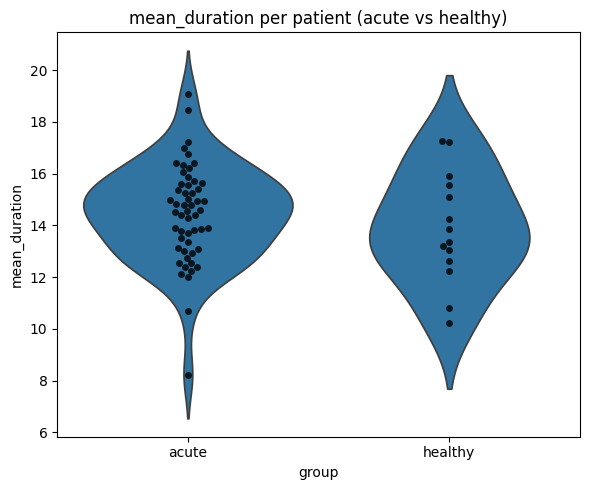

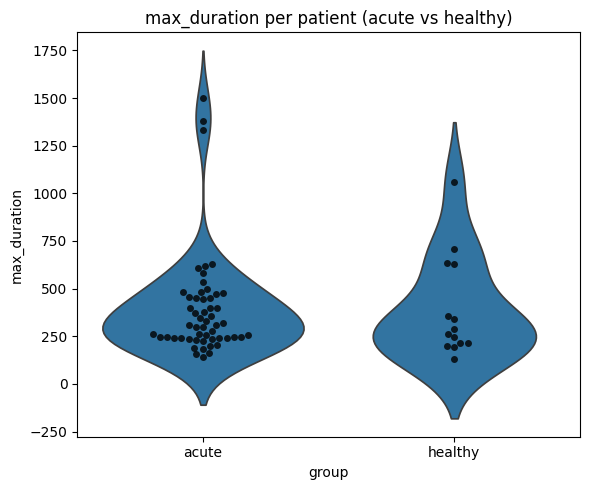

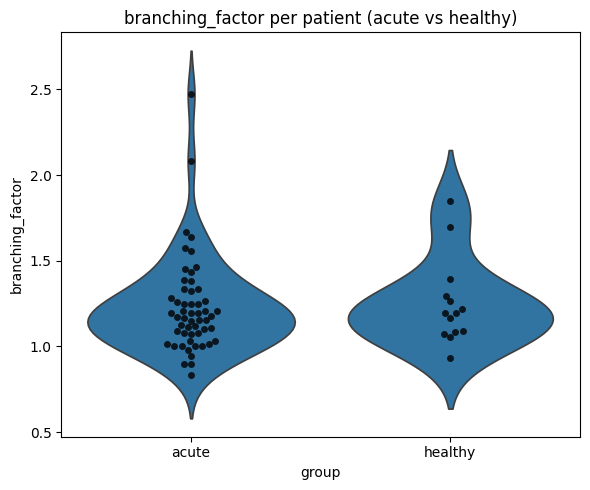

In [6]:
# 3. Statistical analysis
features = ['mean_size', 'max_size', 'mean_duration', 'max_duration', 'branching_factor']

def plot_feature_swarm(df, feature):
    plt.figure(figsize=(6, 5))

    # Create violinplot
    sns.violinplot(
        data=df,
        x="group",
        y=feature,
        inner=None
    )
    # Overlay swarmplot
    sns.swarmplot(
        data=df,
        x="group",
        y=feature,
        color="k",
        alpha=0.8
    )

    plt.title(feature + " per patient (acute vs healthy)")
    plt.tight_layout()
    plt.show()
for feature in features:
    plot_feature_swarm (df_features, feature)


In [7]:

def analyze_feature(df, feature):
    print(f"\n===== {feature} =====")
    
    # 1) descriptive by group
    print("\nDescriptive by group:")
    print(df.groupby("group")[feature].describe()) # for acute and healthy mean, std, min, max, number subjects
    
    acute   = df.loc[df["group"] == "acute", feature].dropna().values
    healthy = df.loc[df["group"] == "healthy", feature].dropna().values
    
    # 2) normalità (solo se ho almeno 3 soggetti)--> lo faccio per decidere che test usare
    sh_acute = sh_healthy = None
    if len(acute) >= 3 and len(healthy) >= 3:
        sh_acute   = stats.shapiro(acute)
        sh_healthy = stats.shapiro(healthy)
        print(f"\nShapiro acute:   p = {sh_acute.pvalue:.3f}")
        print(f"Shapiro healthy: p = {sh_healthy.pvalue:.3f}")
    
    # 3) uguaglianza varianze (se ho almeno 2 per gruppo)
    lev = None
    if len(acute) >= 2 and len(healthy) >= 2:
        lev = stats.levene(acute, healthy)
        print(f"Levene: p = {lev.pvalue:.3f}")
    
    # 4) scelta test
    normal = (
        sh_acute is not None and sh_healthy is not None and
        sh_acute.pvalue > 0.05 and sh_healthy.pvalue > 0.05
    )
    equal_var = (lev is not None and lev.pvalue > 0.05)
    
    if normal and equal_var:
        test_name = "t-test (independent samples)"
        test_res = stats.ttest_ind(acute, healthy, equal_var=True)
        stat, p = test_res.statistic, test_res.pvalue
    else:
        test_name = "Mann-Whitney U"
        test_res = stats.mannwhitneyu(acute, healthy, alternative="two-sided") # two side to controll differences
        stat, p = test_res.statistic, test_res.pvalue
    
    print(f"\nTest usato: {test_name}")
    print(f"Statistic = {stat:.3f}, p = {p:.4f}")
    
    # 5) effect size (Cohen's d) --> in order to have an idea of the magnitude of the difference
    mean_acute   = np.mean(acute)
    mean_healthy = np.mean(healthy)
    var_acute    = np.var(acute, ddof=1)
    var_healthy  = np.var(healthy, ddof=1)
    
    n1, n2 = len(acute), len(healthy)
    std_pooled = np.sqrt(((n1-1)*var_acute + (n2-1)*var_healthy) / (n1+n2-2))
    d = (mean_acute - mean_healthy) / std_pooled if std_pooled > 0 else np.nan
    print(f"Cohen's d = {d:.3f}")
    # interpretation of Cohen's d
    # small effect: d < 0.2
    # medium effect: circa 0.5
    # large effect: d >= 0.8
    
    # 6) AUC (potere classificativo grezzo) --> risultato probabilità che un paziente ascelto a caso tra gli acute abbia un valore di feature piú alto di uno scelto a caso tra gli healthy
    # label: acute=1, healthy=0
    y = (df["group"] == "acute").astype(int).values
    x = df[feature].values
    try:
        auc = roc_auc_score(y, x)
    except ValueError:
        auc = np.nan
    print(f"AUC (single feature) = {auc:.3f}")
    # interpretazione AUC
    # 0.5 = random non discrimina
    # 0.6-0.7 = discrimina poco
    # >0.8 = discrimina bene
    return {
        "feature": feature,
        "test": test_name,
        "stat": stat,
        "p_value": p,
        "effect_size_d": d,
        "auc": auc
    }

results = []
for feature in features:
    res = analyze_feature(df_features, feature)
    results.append(res)
df_results = pd.DataFrame(results)
#print("\n\nSummary of results:")
#print(df_results)

#FDR correction
p_values = df_results["p_value"].values
reject, pvals_corrected, _, _ = multipletests(p_values, method='fdr_bh')
df_results["p_value_fdr"] = pvals_corrected
df_results["reject_null_fdr"] = reject #true solo per le feature che restano significative dopo la correzione
#print("\n\nResults after FDR correction:")
#print(df_results)
display(df_results.sort_values("p_value_fdr"))


===== mean_size =====

Descriptive by group:
         count       mean       std        min        25%        50%  \
group                                                                  
acute     54.0  82.786599  7.211384  65.967576  78.425999  81.881488   
healthy   14.0  78.879707  7.647773  66.138686  74.284826  79.919596   

               75%         max  
group                           
acute    87.522944  102.694239  
healthy  82.133032   92.050136  

Shapiro acute:   p = 0.459
Shapiro healthy: p = 0.902
Levene: p = 0.942

Test usato: t-test (independent samples)
Statistic = 1.785, p = 0.0789
Cohen's d = 0.535
AUC (single feature) = 0.622

===== max_size =====

Descriptive by group:
         count         mean          std     min      25%     50%      75%  \
group                                                                        
acute     54.0  5586.277778  7385.900769  1150.0  2763.75  3591.5  5516.25   
healthy   14.0  5219.071429  3533.732010  1655.0  3047.75  364

,feature,test,stat,p_value,effect_size_d,auc,p_value_fdr,reject_null_fdr
0,mean_size,t-test (independent samples),1.784640,0.078916,0.535234,0.621693,0.394578,False
1,max_size,Mann-Whitney U,343.000000,0.600784,0.053986,0.453704,0.721507,False
2,mean_duration,t-test (independent samples),0.943346,0.348945,0.282921,0.575397,0.721507,False
3,max_duration,Mann-Whitney U,402.000000,0.721507,0.013087,0.531746,0.721507,False
4,branching_factor,Mann-Whitney U,347.000000,0.643636,-0.079923,0.458995,0.721507,False


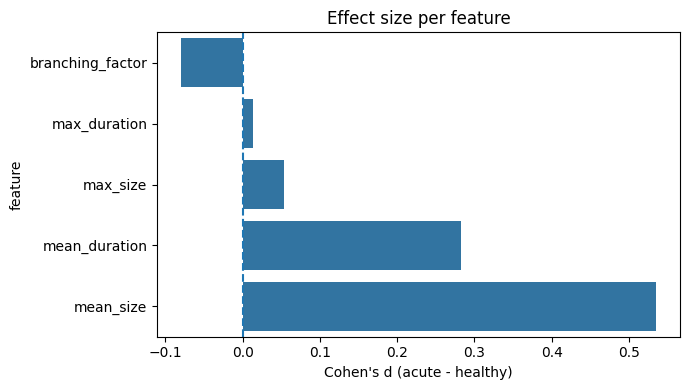

In [8]:
#Barplot effect sizes --> quali feature differiscono di piú tra i gruppi (vicino a 0, poco significativa)
def plot_effect_sizes(results_df):
    df_plot = results_df.sort_values("effect_size_d")

    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=df_plot,
        x="effect_size_d",
        y="feature"
    )
    plt.axvline(0, linestyle="--")
    plt.xlabel("Cohen's d (acute - healthy)")
    plt.title("Effect size per feature")
    plt.tight_layout()
    plt.show()

plot_effect_sizes(df_results)


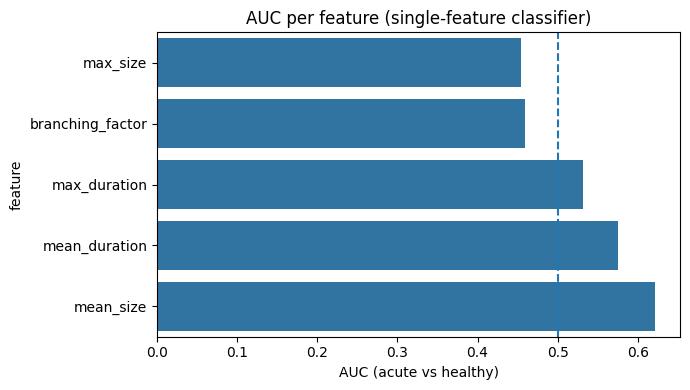

In [9]:
#Barplot AUC per feature --> potere classificativo
def plot_auc_features(results_df):
    df_plot = results_df.sort_values("auc")

    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=df_plot,
        x="auc",
        y="feature"
    )
    plt.axvline(0.5, linestyle="--")  # linea a 0.5 = chance level
    plt.xlabel("AUC (acute vs healthy)")
    plt.title("AUC per feature (single-feature classifier)")
    plt.tight_layout()
    plt.show()

plot_auc_features(df_results)
